**Import Libraries**

In [576]:
import pandas as pd
import numpy as np
import copy

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, cross_validate, KFold
from sklearn.pipeline import Pipeline

**Data Uploading**

In [577]:
data = pd.read_csv('/content/insurance.csv')

In [578]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**EDA and Data Cleaning**

In [579]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [580]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [581]:
data.duplicated().sum()

np.int64(1)

In [582]:
data = data.drop_duplicates()
print(data.shape)

(1337, 7)


In [583]:
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


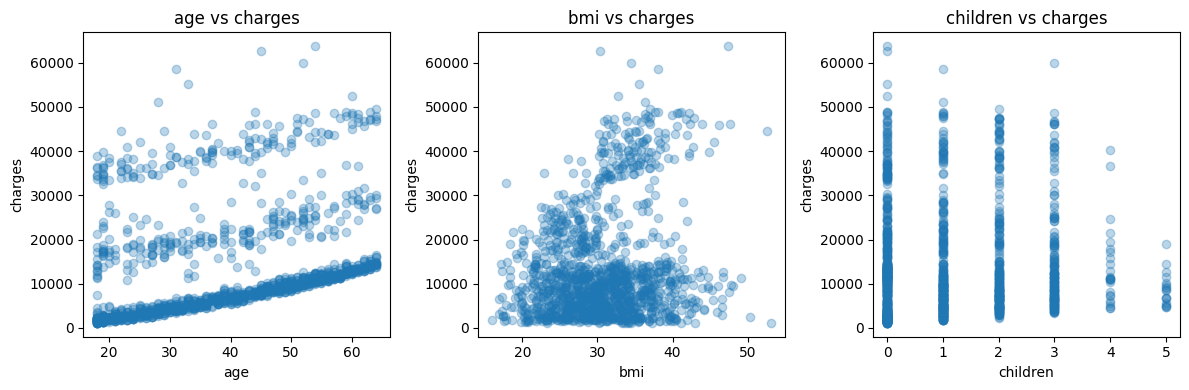

In [584]:
numerical_features = ['age', 'bmi', 'children']

plt.figure(figsize=(12, 4))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    plt.scatter(data[col], data['charges'], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel('charges')
    plt.title(f'{col} vs charges')

plt.tight_layout()
plt.show()

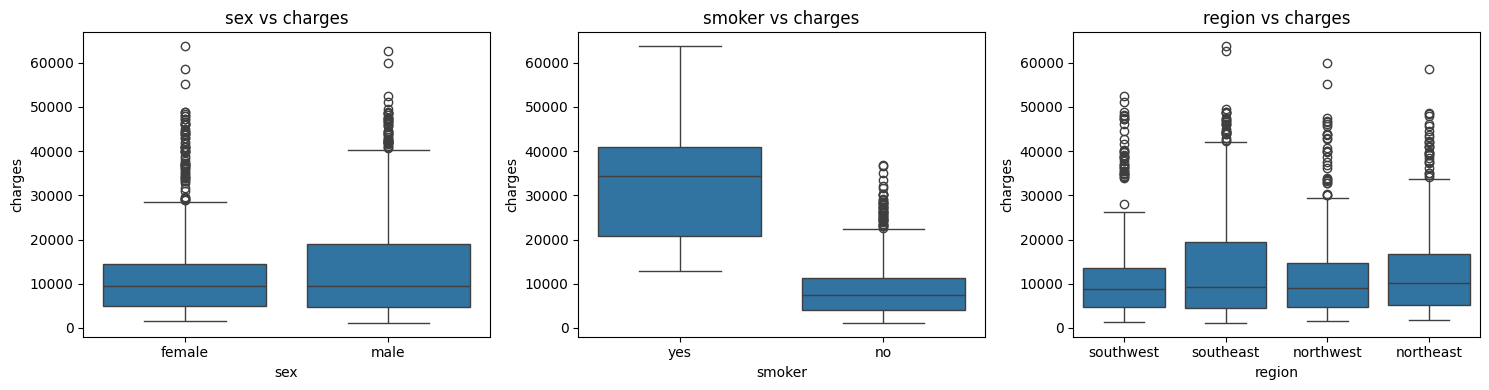

In [585]:
categorical_features = ['sex', 'smoker', 'region']

plt.figure(figsize=(15, 4))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=data[col], y=data['charges'])
    plt.title(f'{col} vs charges')

plt.tight_layout()
plt.show()

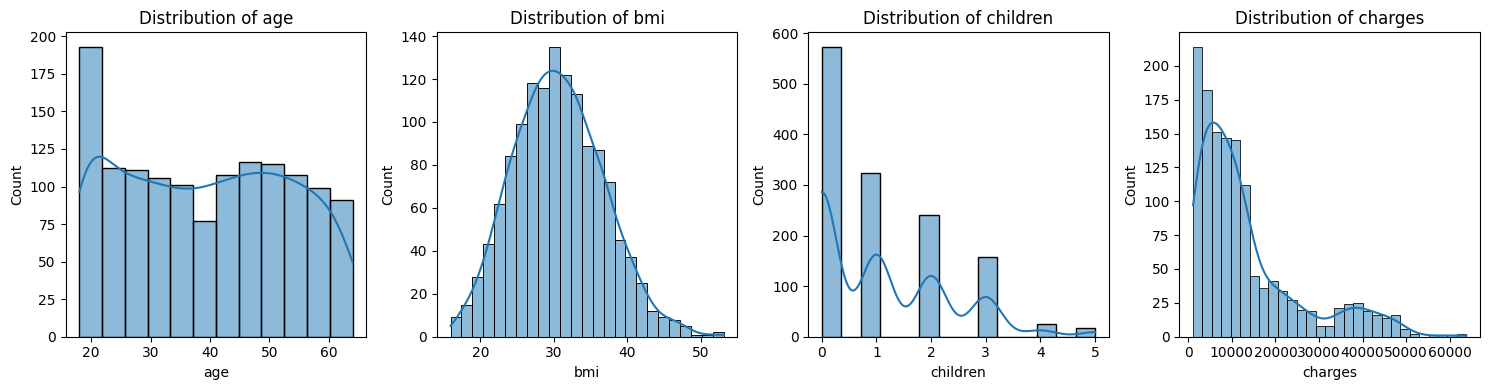

In [586]:
all_features = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(15, 4))

for i, col in enumerate(all_features, 1):
    plt.subplot(1, 4, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

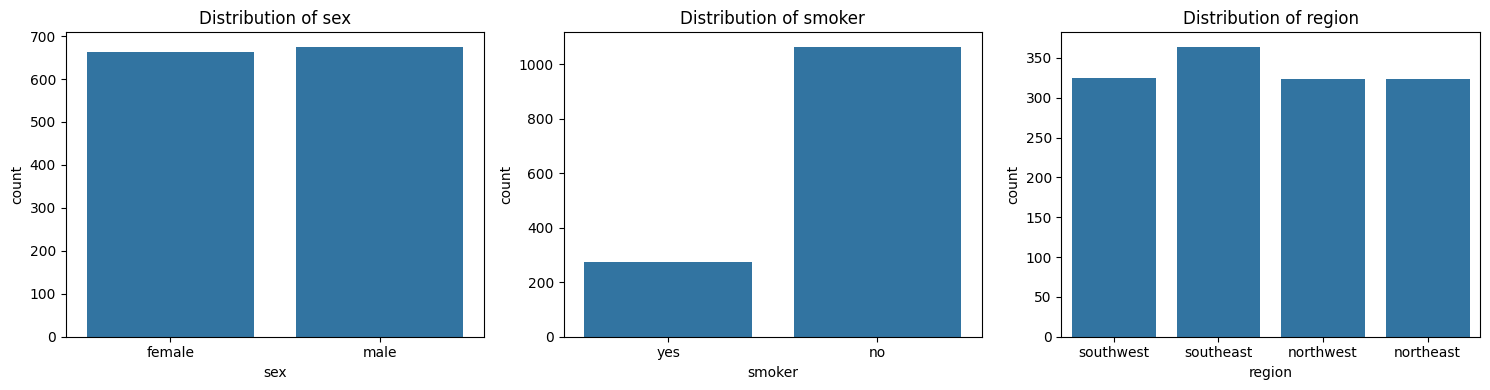

In [587]:
categorical_cols = ['sex', 'smoker', 'region']

plt.figure(figsize=(15, 4))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=data[col])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [588]:
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['smoker'] = data['smoker'].map({'no': 0, 'yes': 1})

data = pd.get_dummies(data, columns=['region'], drop_first=True)

/tmp/ipykernel_4771/2705117405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sex'] = data['sex'].map({'male': 0, 'female': 1})
/tmp/ipykernel_4771/2705117405.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['smoker'] = data['smoker'].map({'no': 0, 'yes': 1})


**Linear Regresing Without any feature
engineering or any thing touches the data**

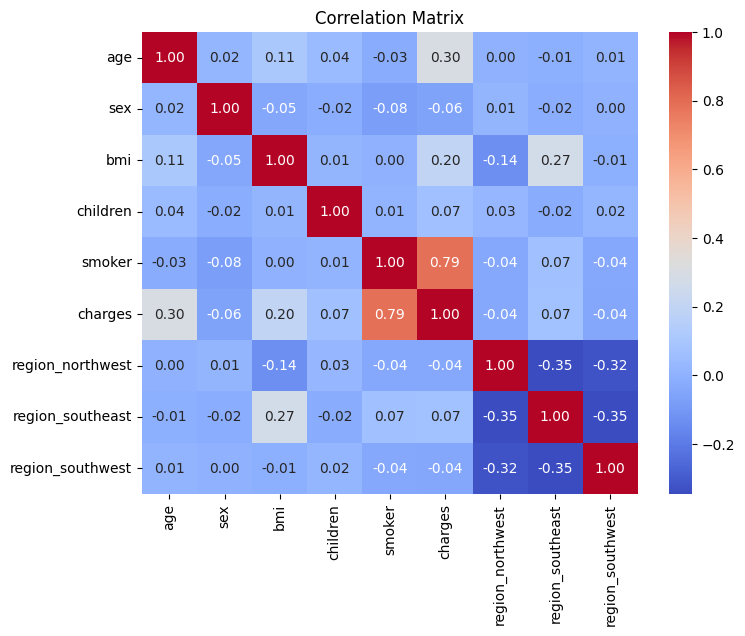

In [589]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [590]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('charges', axis=1), data['charges'], test_size=0.2, random_state=42)

In [591]:
model1 = LinearRegression()
model2 = SGDRegressor()

In [592]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [593]:
model1.fit(X_train_scaled, y_train)
model2.fit(X_train_scaled, y_train)

SGDRegressor()

In [594]:
y_pred1 = model1.predict(X_test_scaled)
y_pred2 = model2.predict(X_test_scaled)

In [595]:
print('Model 1 - Linear Regression')
print('R2 Score:', r2_score(y_test, y_pred1))
print('MSE Score:', mean_squared_error(y_test, y_pred1))
print('MAE Score:', mean_absolute_error(y_test, y_pred1))
print('RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred1)))
print('\n---------------------------------------------\n')
print('Model 2 - SGD Regressor')
print('R2 Score:', r2_score(y_test, y_pred2))
print('MSE Score:', mean_squared_error(y_test, y_pred2))
print('MAE Score:', mean_absolute_error(y_test, y_pred2))
print('RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred2)))

Model 1 - Linear Regression
R2 Score: 0.8069287081198012
MSE Score: 35478020.67523559
MAE Score: 4177.045561036323
RMSE Score: 5956.342894363587

---------------------------------------------

Model 2 - SGD Regressor
R2 Score: 0.8075680973081903
MSE Score: 35360529.03458678
MAE Score: 4177.209561954024
RMSE Score: 5946.471982157721


In [596]:
cv_scores1 = cross_val_score(model1, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores2 = cross_val_score(model2, X_train_scaled, y_train, cv=5, scoring='r2')

print('Model 1 - Linear Regression')
print(f"CV R² Scores: {cv_scores1}")
print(f"Mean R²:      {cv_scores1.mean():.4f}")
print(f"Std R²:       {cv_scores1.std():.4f}")

print('\n---------------------------------------------\n')

print('Model 2 - SGD Regressor')
print(f"CV R² Scores: {cv_scores2}")
print(f"Mean R²:      {cv_scores2.mean():.4f}")
print(f"Std R²:       {cv_scores2.std():.4f}")

Model 1 - Linear Regression
CV R² Scores: [0.69409981 0.76357239 0.72107631 0.70579211 0.74424615]
Mean R²:      0.7258
Std R²:       0.0253

---------------------------------------------

Model 2 - SGD Regressor
CV R² Scores: [0.69439311 0.76279132 0.7209338  0.70617169 0.74404463]
Mean R²:      0.7257
Std R²:       0.0249


**Linear Regresing With feature engineering**

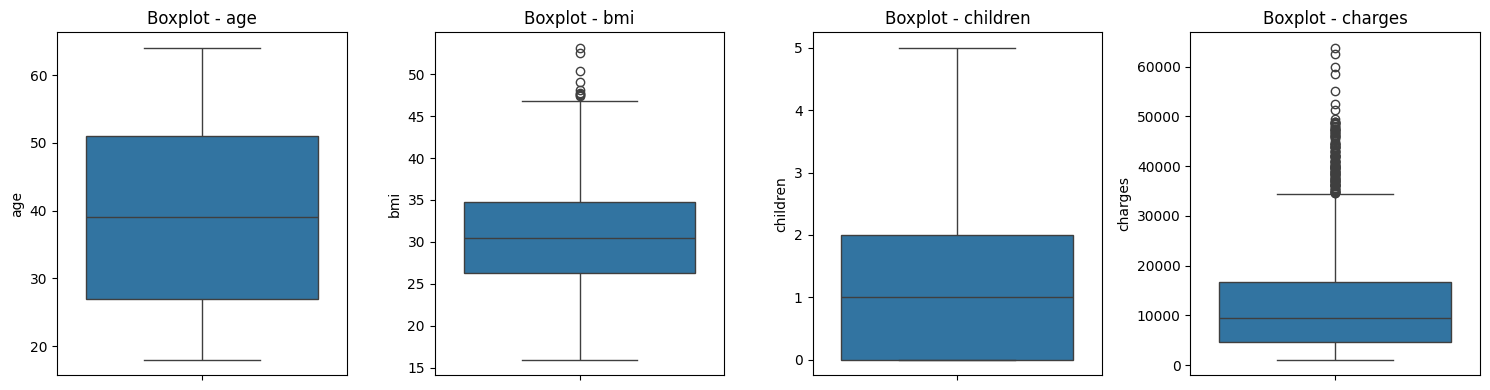

In [597]:
plt.figure(figsize=(15, 4))

for i, col in enumerate(['age', 'bmi', 'children', 'charges'], 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

In [598]:
for col in ['age', 'bmi', 'children', 'charges']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < Q1 - 1.5 * IQR) | (data[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


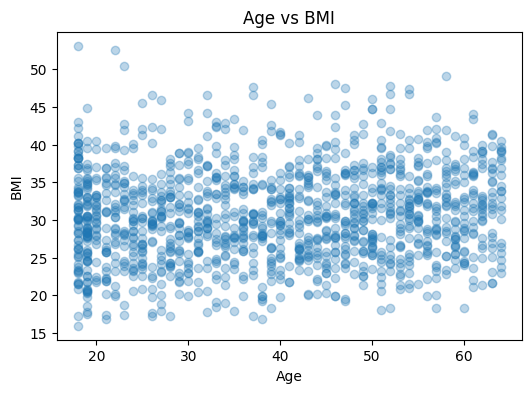

In [599]:
plt.figure(figsize=(6, 4))
plt.scatter(data['age'], data['bmi'], alpha=0.3)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI')
plt.show()

In [600]:
data['smoker_bmi'] = data['smoker'] * data['bmi']
data['bmi_category'] = (data['bmi'] >= 30).astype(int)
data['obese_smoker'] = data['bmi_category'] * data['smoker']
#data['age_smoker'] = data['age'] * data['smoker'] no impact
#data['age_children'] = data['age'] * data['children']  no impact

In [601]:
data

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,smoker_bmi,bmi_category,obese_smoker
0,19,1,27.900,0,1,16884.92400,False,False,True,27.90,0,0
1,18,0,33.770,1,0,1725.55230,False,True,False,0.00,1,0
2,28,0,33.000,3,0,4449.46200,False,True,False,0.00,1,0
3,33,0,22.705,0,0,21984.47061,True,False,False,0.00,0,0
4,32,0,28.880,0,0,3866.85520,True,False,False,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,0.00,1,0
1334,18,1,31.920,0,0,2205.98080,False,False,False,0.00,1,0
1335,18,1,36.850,0,0,1629.83350,False,True,False,0.00,1,0
1336,21,1,25.800,0,0,2007.94500,False,False,True,0.00,0,0


In [602]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('charges', axis=1), data['charges'], test_size=0.2, random_state=42)

In [603]:
model1 = LinearRegression()
model2 = SGDRegressor()

In [604]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [605]:
model1.fit(X_train_scaled, y_train)
model2.fit(X_train_scaled, y_train)

SGDRegressor()

In [606]:
y_pred1 = model1.predict(X_test_scaled)
y_pred2 = model2.predict(X_test_scaled)

In [607]:
print('Model 1 - Linear Regression')
print('R2 Score:', r2_score(y_test, y_pred1))
print('MSE Score:', mean_squared_error(y_test, y_pred1))
print('MAE Score:', mean_absolute_error(y_test, y_pred1))
print('RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred1)))
print('\n---------------------------------------------\n')
print('Model 2 - SGD Regressor')
print('R2 Score:', r2_score(y_test, y_pred2))
print('MSE Score:', mean_squared_error(y_test, y_pred2))
print('MAE Score:', mean_absolute_error(y_test, y_pred2))
print('RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred2)))

Model 1 - Linear Regression
R2 Score: 0.9091688217685012
MSE Score: 16690779.804035803
MAE Score: 2276.4547139959127
RMSE Score: 4085.4350813635265

---------------------------------------------

Model 2 - SGD Regressor
R2 Score: 0.9093674395969913
MSE Score: 16654282.573624067
MAE Score: 2287.8109886521424
RMSE Score: 4080.9658873389358


In [608]:
cv_scores1 = cross_val_score(model1, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores2 = cross_val_score(model2, X_train_scaled, y_train, cv=5, scoring='r2')

print('Model 1 - Linear Regression')
print(f"CV R² Scores: {cv_scores1}")
print(f"Mean R²:      {cv_scores1.mean():.4f}")
print(f"Std R²:       {cv_scores1.std():.4f}")

print('\n---------------------------------------------\n')

print('Model 2 - SGD Regressor')
print(f"CV R² Scores: {cv_scores2}")
print(f"Mean R²:      {cv_scores2.mean():.4f}")
print(f"Std R²:       {cv_scores2.std():.4f}")

Model 1 - Linear Regression
CV R² Scores: [0.80622113 0.87864817 0.8473675  0.8594974  0.86398907]
Mean R²:      0.8511
Std R²:       0.0246

---------------------------------------------

Model 2 - SGD Regressor
CV R² Scores: [0.80509619 0.87872191 0.84793613 0.85895631 0.86212806]
Mean R²:      0.8506
Std R²:       0.0248


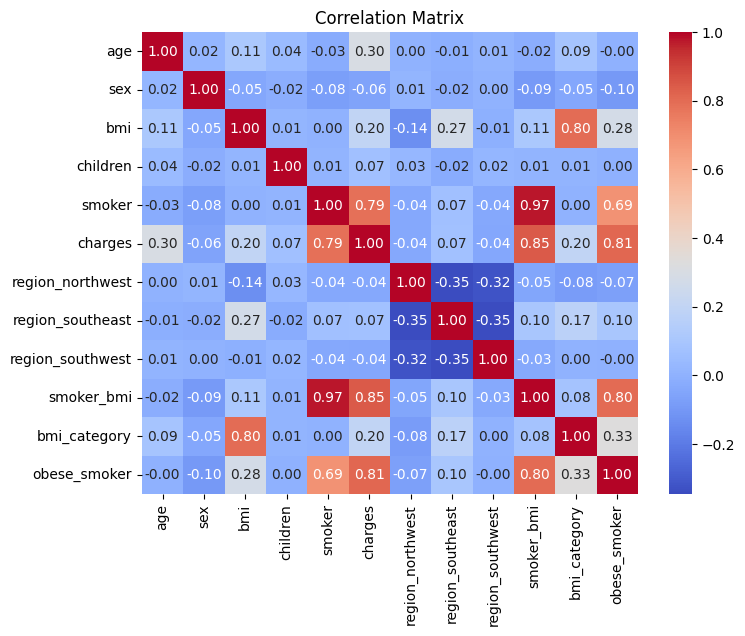

In [609]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Results with apllying log transformation on charges**

In [610]:
# Save original charges
y_original = data['charges'].copy()

# Apply log transformation
data['charges'] = np.log1p(data['charges'])

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(data.drop('charges', axis=1), data['charges'], test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict and reverse transformation
y_pred_log = model.predict(X_test_scaled)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# Evaluate on actual dollar values
print('With Log Transformation on Charges')
print(f"R²:   {r2_score(y_test_actual, y_pred_actual):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_actual, y_pred_actual):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)):.4f}")

# Restore original charges
data['charges'] = y_original

With Log Transformation on Charges
R²:   0.6567
MAE:  3981.5377
RMSE: 7942.3687
